# Tối ưu hóa siêu tham số (Hyperparameter Optimization) với Optuna và TensorFlow

---

Notebook này giúp bạn tự động tìm ra bộ tham số tốt nhất cho mô hình thay vì phải dò tay.
- `learning_rate`: Tốc độ học
- `scheduler_type`: Chọn giữa `none`, `step`, `cosine`, `exponential`, `reduce`
- `weight_decay`: Trọng số suy giảm của `AdamW`
- `loss_type`: Chọn giữa `BinaryCrossentropy` (ce) hoặc `BinaryFocalCrossentropy` (focal)
- `label_smoothing`: Tham số làm giảm độ tự tin quá mức của mô hình, được sử dụng khi dùng `BinaryCrossEntropy`
- `gamma`: Tham số cho `Focal Loss` nhằm tập trung vào mẫu khó, được sử dụng khi dùng `BinaryFocalCrossentropy`


In [12]:
import os
import sys
import optuna
import optuna.visualization.matplotlib as vis
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from optuna.integration import TFKerasPruningCallback
from optuna.pruners import MedianPruner
from keras.optimizers import AdamW
from keras.losses import BinaryCrossentropy, BinaryFocalCrossentropy
from keras.optimizers.schedules import CosineDecay, ExponentialDecay
from keras.callbacks import ReduceLROnPlateau
from keras.utils import image_dataset_from_directory, set_random_seed

sys.path.append(os.path.abspath('..'))
from models.CustomeModel import custome_model
from src.evaluate import MetricsCallback

# Cấu hình chung
IMG_SIZE = 224
BATCH_SIZE = 32
TRIAL_EPOCHS = 6
N_TRIALS = 20
SEED = 42

set_random_seed(SEED)


## 1. Chuẩn bị dữ liệu

---

In [2]:
train_dir = '../datasets/LCC_FASD/train'
val_dir = '../datasets/LCC_FASD/val'

print("Tập Train:")
train_ds = image_dataset_from_directory(
    train_dir, 
    image_size=(IMG_SIZE, IMG_SIZE), 
    batch_size=BATCH_SIZE, 
    label_mode='binary',
    shuffle=True,
    seed=SEED
)

print("\nTập Validation:")
val_ds = image_dataset_from_directory(
    val_dir, 
    image_size=(IMG_SIZE, IMG_SIZE), 
    batch_size=BATCH_SIZE, 
    label_mode='binary',
    shuffle=False
)

# Nạp dữ liệu song song để tăng tốc
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


Tập Train:
Found 8223 files belonging to 2 classes.


E0000 00:00:1791522727.112657  448631 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



Tập Validation:
Found 2934 files belonging to 2 classes.


## 2. Định nghĩa hàm Objective cho Optuna

---

In [3]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 5e-2, log=True)
    loss_type = trial.suggest_categorical("loss_type", ["ce", "focal"])
    scheduler_type = trial.suggest_categorical("scheduler_type", ["none", "step", "cosine", "exponential", "reduce"])
    
    label_smoothing = None
    gamma = None
    
    if loss_type == "ce":
        label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.1)
        loss_fn = BinaryCrossentropy(label_smoothing=label_smoothing)
    else:
        gamma = trial.suggest_float("gamma", 0.5, 3.0)
        loss_fn = BinaryFocalCrossentropy(gamma=gamma)
        
    steps_per_epoch = len(train_ds)
    if scheduler_type == "none":
        lr_schedule = lr
    elif scheduler_type == "cosine":
        lr_schedule = CosineDecay(
            initial_learning_rate=lr,
            decay_steps=TRIAL_EPOCHS * steps_per_epoch
        )
    elif scheduler_type == "exponential":
        lr_schedule = ExponentialDecay(
            initial_learning_rate=lr,
            decay_steps=steps_per_epoch,
            decay_rate=0.9,
            staircase=False
        )
    elif scheduler_type == "step":
        lr_schedule = ExponentialDecay(
            initial_learning_rate=lr,
            decay_steps=steps_per_epoch,
            decay_rate=0.5,
            staircase=True
        )
    elif scheduler_type == "reduce":
        lr_schedule = lr
        reduce = ReduceLROnPlateau(
            monitor="val_loss", 
            factor=0.5, 
            patience=2, 
            min_lr=1e-6
        )
        
    keras.backend.clear_session() 

    model = custome_model(input_shape=(IMG_SIZE, IMG_SIZE, 3))

    optimizer = AdamW(learning_rate=lr_schedule, weight_decay=weight_decay, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
    
    class_weight = {0: 3.37, 1: 0.58}
    metrics_cb = MetricsCallback(val_dataset=val_ds)

    callbacks_list = [metrics_cb, TFKerasPruningCallback(trial, 'val_loss')] + ([reduce] if scheduler_type == "reduce" else [])
    
    print(f"-> Bắt đầu Trial {trial.number} lr={lr:.5f}, schedule={scheduler_type}, weight_decay={weight_decay}, loss={loss_type}, label_smoothing={label_smoothing}, gamma={gamma}")
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=TRIAL_EPOCHS,
        callbacks=callbacks_list,
        class_weight=class_weight,
        shuffle=False,
        verbose=0
    )

    val_acer = metrics_cb.best_acer
    print(f"-> Kết thúc Trial {trial.number}] ACER Tốt nhất đạt: {val_acer*100:.2f}%")
    
    return val_acer


## 3. Chạy quá trình tìm kiếm (Optimize)

---

In [4]:
study = optuna.create_study(direction="minimize", pruner=MedianPruner(n_startup_trials=2, n_warmup_steps=3))

study.enqueue_trial({"lr": 4e-4, "scheduler_type": "none", "weight_decay": 1e-4, "label_smoothing": 0.05, "loss_type": "ce"})

study.optimize(objective, n_trials=N_TRIALS)

[I 2026-10-09 12:12:07,256] A new study created in memory with name: no-name-e2feb479-fd1e-4e68-970c-38d5da7810b9


-> Bắt đầu Trial 0 lr=0.00040, schedule=none, weight_decay=0.0001, loss=ce, label_smoothing=0.05, gamma=None
 - APCER: 28.79% - BPCER: 28.89% - EER: 28.84% - ACER: 28.84% (t*: 0.7039) ⭐ NEW BEST
 - APCER: 30.57% - BPCER: 30.62% - EER: 30.59% - ACER: 30.59% (t*: 0.8887) 
 - APCER: 20.25% - BPCER: 20.25% - EER: 20.25% - ACER: 20.25% (t*: 0.7828) ⭐ NEW BEST
 - APCER: 23.41% - BPCER: 23.46% - EER: 23.43% - ACER: 23.43% (t*: 0.1290) 
 - APCER: 15.90% - BPCER: 15.80% - EER: 15.85% - ACER: 15.85% (t*: 0.2405) ⭐ NEW BEST


[I 2026-10-09 12:18:53,585] Trial 0 finished with value: 0.1584904002460349 and parameters: {'lr': 0.0004, 'weight_decay': 0.0001, 'loss_type': 'ce', 'scheduler_type': 'none', 'label_smoothing': 0.05}. Best is trial 0 with value: 0.1584904002460349.


 - APCER: 16.37% - BPCER: 16.30% - EER: 16.33% - ACER: 16.33% (t*: 0.1791) 
-> Kết thúc Trial 0] ACER Tốt nhất đạt: 15.85%
-> Bắt đầu Trial 1 lr=0.00001, schedule=step, weight_decay=1.7612877513829833e-05, loss=ce, label_smoothing=0.03154898955226271, gamma=None
 - APCER: 26.77% - BPCER: 26.67% - EER: 26.72% - ACER: 26.72% (t*: 0.5277) ⭐ NEW BEST
 - APCER: 23.29% - BPCER: 23.21% - EER: 23.25% - ACER: 23.25% (t*: 0.5590) ⭐ NEW BEST
 - APCER: 21.31% - BPCER: 22.22% - EER: 21.77% - ACER: 21.77% (t*: 0.4772) ⭐ NEW BEST
 - APCER: 21.59% - BPCER: 21.98% - EER: 21.78% - ACER: 21.78% (t*: 0.4533) 
 - APCER: 21.95% - BPCER: 21.98% - EER: 21.96% - ACER: 21.96% (t*: 0.4500) 


[I 2026-10-09 12:25:39,277] Trial 1 finished with value: 0.2171829005755459 and parameters: {'lr': 1.4231706913317232e-05, 'weight_decay': 1.7612877513829833e-05, 'loss_type': 'ce', 'scheduler_type': 'step', 'label_smoothing': 0.03154898955226271}. Best is trial 0 with value: 0.1584904002460349.


...

 - APCER: 17.24% - BPCER: 17.28% - EER: 17.26% - ACER: 17.26% (t*: 0.4532) ⭐ NEW BEST
-> Kết thúc Trial 17] ACER Tốt nhất đạt: 17.26%
-> Bắt đầu Trial 18 lr=0.00039, schedule=exponential, weight_decay=0.017706286729631978, loss=focal, label_smoothing=None, gamma=1.858747635735457
 - APCER: 23.57% - BPCER: 23.46% - EER: 23.51% - ACER: 23.51% (t*: 0.5765) ⭐ NEW BEST
 - APCER: 28.98% - BPCER: 28.89% - EER: 28.94% - ACER: 28.94% (t*: 0.7730) 
 - APCER: 18.78% - BPCER: 19.01% - EER: 18.90% - ACER: 18.90% (t*: 0.6600) ⭐ NEW BEST
 - APCER: 24.24% - BPCER: 23.95% - EER: 24.09% - ACER: 24.09% (t*: 0.5986) 
 - APCER: 19.81% - BPCER: 19.75% - EER: 19.78% - ACER: 19.78% (t*: 0.7257) 


[I 2026-10-09 14:22:56,433] Trial 18 finished with value: 0.18329159527261543 and parameters: {'lr': 0.0003892622357852283, 'weight_decay': 0.017706286729631978, 'loss_type': 'focal', 'scheduler_type': 'exponential', 'gamma': 1.858747635735457}. Best is trial 13 with value: 0.1349237731206889.


 - APCER: 18.39% - BPCER: 18.27% - EER: 18.33% - ACER: 18.33% (t*: 0.4361) ⭐ NEW BEST
-> Kết thúc Trial 18] ACER Tốt nhất đạt: 18.33%
-> Bắt đầu Trial 19 lr=0.00045, schedule=cosine, weight_decay=0.00012064781096974135, loss=focal, label_smoothing=None, gamma=1.851317075263688
 - APCER: 33.89% - BPCER: 33.83% - EER: 33.86% - ACER: 33.86% (t*: 0.5920) ⭐ NEW BEST
 - APCER: 24.00% - BPCER: 23.46% - EER: 23.73% - ACER: 23.73% (t*: 0.7664) ⭐ NEW BEST
 - APCER: 16.69% - BPCER: 17.04% - EER: 16.86% - ACER: 16.86% (t*: 0.6755) ⭐ NEW BEST
 - APCER: 16.21% - BPCER: 16.05% - EER: 16.13% - ACER: 16.13% (t*: 0.3839) ⭐ NEW BEST
 - APCER: 13.84% - BPCER: 13.83% - EER: 13.83% - ACER: 13.83% (t*: 0.3982) ⭐ NEW BEST


[I 2026-10-09 14:31:07,340] Trial 19 finished with value: 0.13833311365932954 and parameters: {'lr': 0.0004512283369187966, 'weight_decay': 0.00012064781096974135, 'loss_type': 'focal', 'scheduler_type': 'cosine', 'gamma': 1.851317075263688}. Best is trial 13 with value: 0.1349237731206889.


 - APCER: 15.38% - BPCER: 15.31% - EER: 15.35% - ACER: 15.35% (t*: 0.4169) 
-> Kết thúc Trial 19] ACER Tốt nhất đạt: 13.83%


## 4. Đánh giá kết quả

---

In [5]:
print(f"ACER nhỏ nhất đạt được: {study.best_value * 100:.2f}%")
print("\nBộ tham số tối ưu:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

df = study.trials_dataframe()
df_sorted = df.sort_values(by="value").head(10)

display_cols = ["number", "value", "params_lr", "params_scheduler_type", "params_loss_type", "params_weight_decay", "params_label_smoothing", "params_gamma"]
display_cols = [c for c in display_cols if c in df_sorted.columns]

print("\nTOP TRIALS TỐT NHẤT:")
display(df_sorted[display_cols].fillna("-"))

ACER nhỏ nhất đạt được: 13.49%

Bộ tham số tối ưu:
  - lr: 0.0003505976014961304
  - weight_decay: 0.0018516374542249677
  - loss_type: focal
  - scheduler_type: cosine
  - gamma: 2.101524016764993

TOP TRIALS TỐT NHẤT:


,number,value,params_lr,params_scheduler_type,params_loss_type,params_weight_decay,params_label_smoothing,params_gamma
13,13,0.134924,0.000351,cosine,focal,0.001852,-,2.101524
19,19,0.138333,0.000451,cosine,focal,0.000121,-,1.851317
16,16,0.138729,0.000287,cosine,focal,0.011473,-,1.914727
0,0,0.158490,0.000400,none,ce,0.000100,0.05,-
12,12,0.161504,0.000316,cosine,focal,0.000925,-,0.544376
17,17,0.172620,0.000157,cosine,focal,0.008728,-,1.804306
6,6,0.175634,0.000069,none,focal,0.000014,-,0.750828
3,3,0.176917,0.000024,none,ce,0.000511,0.007105,-
5,5,0.177264,0.000214,none,ce,0.000043,0.041962,-
4,4,0.177857,0.000289,step,ce,0.000518,0.052884,-


/tmp/ipykernel_448631/661088150.py:8: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = vis.plot_optimization_history(study)


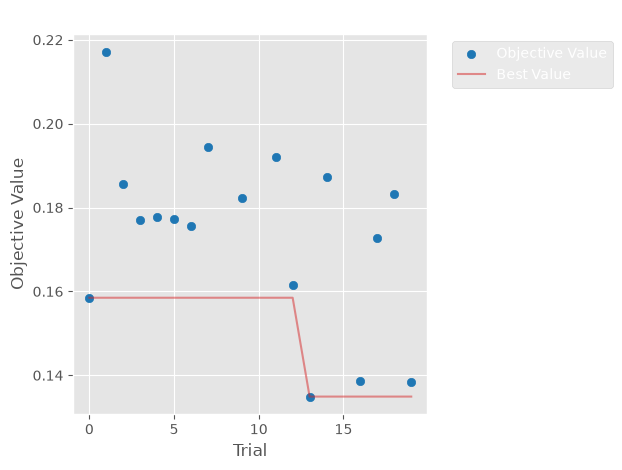

In [11]:
plt.style.use('dark_background')

fig = vis.plot_optimization_history(study)
plt.title("Lịch sử Tối ưu hóa (Optimization History)", fontsize=14)
plt.tight_layout()
plt.show()


/tmp/ipykernel_448631/1113698301.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = vis.plot_param_importances(study)


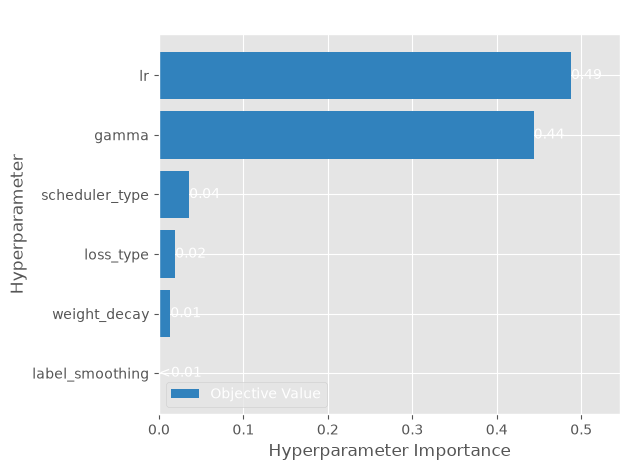

In [13]:
# 2. Mức độ quan trọng của các tham số (Parameter Importances)
fig = vis.plot_param_importances(study)
plt.title("Mức độ Quan trọng của Siêu tham số", fontsize=14)
plt.tight_layout()
plt.show()


### Kết luận

---

Sau khi kiểm tra và đánh giá toàn bộ kết quả sau khi sử dụng thư viện `optuna` để tìm kiếm tham số và phương pháp tối ưu, chúng tôi nhận thấy rằng kết quả sẽ được cải thiện nhất với 3 trials đầu tiên với kết quả `ACER` rơi vào khoảng `13%` tốt nhât trong cấc trials. Đặc điểm chung của 3 trials này chính là đều sử dụng `cosin` để giảm `learning_rate`, sử dụng `focal loss` kết hợp với `gamma` (dao trộng trong khoảng 2) nhằm tăng cường tập trung vào các mẫu khó. Điều này là chính xác bởi sau bước khám phá dữ liệu ở notebook [01_Explore.ipynb](01_Explore.ipynb) đã cho thấy rằng có rất nhiều bức ảnh có điều kiện môi trường rất khác nhau và rất mạnh. Vì vậy `cosin` và `Focal Loss` kết hợp kết quả trung bình của 3 trials tốt nhất của `gamma` là `2.00`. Ngoài ra, tham số quan trọng nhất trong việc huấn luyện chính là `learning_rate` cúa 3 trials đầu là `4e-4`, `3e-4` và `2e-4`, mạnh nhất là `3e-4`, do đó chúng tôi quyết định lấy trung bình cả 3 bằng `0.000363` làm tham số cơ bản cho các mô hình sau. Cuối cùng là `weight_decay` cũng là một tham số quyết định cho `AdamW`, mặc dù biểu đồ trực quan cho thấy nó không quan trọng và chúng tôi nhận thấy 3 trials tốt nhất đều dao động khá mạnh, vì thế chúng tôi quết định lấy kết quả tốt nhất làm tham số `weight_decay` cho `AdamW` ở các mô hình sau là `0.002`.

**Tham số tối ưu cuối cùng:**
- `learning_rate`: 0.000363
- `schedular`: cosin
- `loss`: Focal Loss
- `gamma`: 2.00
- `weight_decay`: 0.002